In [1]:
import sys
sys.path.append('..')
import torch
from utils import *
import matplotlib.pyplot as plt

device = "cuda"

In [2]:
def compute_sas(datahandler: DataHandler, B: int = 10):
    """计算B个频率块的Spectral Alignment Score"""
    num_users = datahandler.num_users
    num_items = datahandler.num_items
    n = num_users + num_items
    dev = datahandler.device

    # 构建二部图归一化邻接矩阵 D^{-1/2} A D^{-1/2}
    A = torch.zeros(n, n, device=dev)
    A[:num_users, num_users:] = datahandler.rate_matrix
    A[num_users:, :num_users] = datahandler.rate_matrix.T

    deg = A.sum(dim=1)
    deg_inv_sqrt = torch.zeros_like(deg)
    nonzero = deg > 0
    deg_inv_sqrt[nonzero] = 1.0 / deg[nonzero].sqrt()
    D_inv_sqrt = torch.diag(deg_inv_sqrt)
    A_norm = D_inv_sqrt @ A @ D_inv_sqrt

    # 特征分解 (eigh返回升序)
    (eigenvalues, eigenvectors) = torch.linalg.eigh(A_norm)

    # 对拼接语义嵌入做SVD: concat = P diag(sigma) Q^T
    concat = torch.cat([datahandler.user_semantic_embeddings,
                        datahandler.item_semantic_embeddings], dim=0)
    (P, sigma, Q_T) = torch.linalg.svd(concat, full_matrices=False)

    r = P.shape[1]       # 秩
    d_c = r // B         # 每个频率块的列数 / 协同子空间维度

    # top-d_c特征向量 (低频 = 最大特征值 = eigh结果的最后d_c列)
    V_dc = eigenvectors[:, -d_c:]

    # 对每个频率块计算SAS
    sas_values = []
    for b in range(B):
        start = b * d_c
        end = (b + 1) * d_c if b < B - 1 else r
        P_b = P[:, start:end]

        proj = V_dc @ (V_dc.T @ P_b)
        sas = (torch.norm(proj, p='fro')**2 / torch.norm(P_b, p='fro')**2).item()
        sas_values.append(sas)

    return sas_values, r, d_c

In [3]:
B = 10
datahandler = DataHandler(interaction_data="games", semantic_data="qwen", device=device)
sas_values, r, d_c = compute_sas(datahandler, B)

print(f"r={r}, B={B}, d_c={d_c}")
for i, sas in enumerate(sas_values):
    print(f"  Band {i+1} (col {i*d_c+1}-{min((i+1)*d_c, r)}): SAScore = {sas:.4f}")

r=4096, B=10, d_c=409
  Band 1 (col 1-409): SAScore = 0.2509
  Band 2 (col 410-818): SAScore = 0.1751
  Band 3 (col 819-1227): SAScore = 0.1456
  Band 4 (col 1228-1636): SAScore = 0.1250
  Band 5 (col 1637-2045): SAScore = 0.1105
  Band 6 (col 2046-2454): SAScore = 0.1004
  Band 7 (col 2455-2863): SAScore = 0.0512
  Band 8 (col 2864-3272): SAScore = 0.0031
  Band 9 (col 3273-3681): SAScore = 0.0032
  Band 10 (col 3682-4090): SAScore = 0.0033


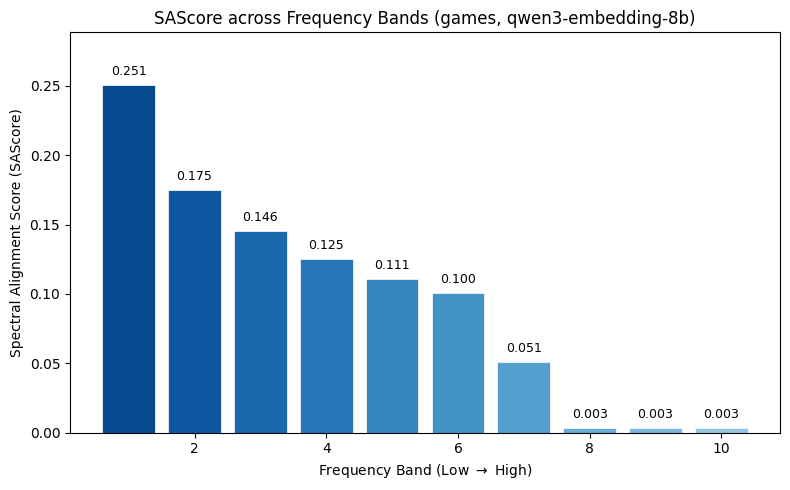

In [5]:
# 单数据集SAS柱状图
fig, ax = plt.subplots(figsize=(8, 5))

colors = [plt.cm.Blues(0.9 - 0.5 * i / (B - 1)) for i in range(B)]
bars = ax.bar(range(1, B + 1), sas_values, color=colors, edgecolor='white', linewidth=0.5)

for bar, sas in zip(bars, sas_values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f'{sas:.3f}', ha='center', va='bottom', fontsize=9)

ax.set_xlabel('Frequency Band (Low $\\rightarrow$ High)')
ax.set_ylabel('Spectral Alignment Score (SAScore)')
ax.set_title('SAScore across Frequency Bands (games, qwen3-embedding-8b)')
ax.set_ylim(0, max(sas_values) * 1.15)
plt.tight_layout()
plt.show()